# 1. Import and Hardware Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageDraw, ImageFont
import os
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import glob
import json

!pip install tqdm kagglehub albumentations timm -q
import timm
import kagglehub
from tqdm.auto import tqdm

# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import albumentations as A
from albumentations.pytorch import ToTensorV2

Using device: cuda


# 2. Hyperparameters

In [2]:
# Image settings
IMG_SIZE = 448             # YOLOv1 standard input resolution (paper: 448x448)
IN_CHANNELS = 3            # RGB images
NUM_CLASSES = 20           # 20 Pascal VOC object classes (no background class in YOLOv1)

# Class names (index 0..19, no background)
CLASS_NAMES = [
    "aeroplane",      # 0
    "bicycle",        # 1
    "bird",           # 2
    "boat",           # 3
    "bottle",         # 4
    "bus",            # 5
    "car",            # 6
    "cat",            # 7
    "chair",          # 8
    "cow",            # 9
    "diningtable",    # 10
    "dog",            # 11
    "horse",          # 12
    "motorbike",      # 13
    "person",         # 14
    "pottedplant",    # 15
    "sheep",          # 16
    "sofa",           # 17
    "train",          # 18
    "tvmonitor",      # 19
]

# Training settings
BATCH_SIZE = 16
LR = 1e-4                  # Initial learning rate for AdamW
EPOCHS = 100
SEED = 42
WEIGHT_DECAY = 5e-4

# Backbone freeze and warmup settings (stabilizes early training)
WARMUP_EPOCHS = 5           # Linear LR warmup from 1% to full LR
FREEZE_BACKBONE_EPOCHS = 5  # Train only the detection head for the first N epochs

# YOLOv1-specific settings (paper: Redmon et al., 2015)
S = 7                       # Grid size (S x S)
B = 2                       # Number of bounding boxes per grid cell
LAMBDA_COORD = 5.0          # Weight for coordinate loss
LAMBDA_NOOBJ = 0.5          # Weight for no-object confidence loss
CONF_THRESHOLD = 0.2        # Confidence threshold for detection
NMS_THRESHOLD = 0.45        # Non-Maximum Suppression IoU threshold

# Early stopping patience
PATIENCE = 5

print("Done!")

Done!


# 3. Dataset Download

In [3]:
# Download Pascal VOC 2012 object detection dataset via kagglehub
DATASET_PATH = kagglehub.dataset_download("banuprasadb/pascal-voc-2012")
print(f"Dataset downloaded to: {DATASET_PATH}")

# Auto-detect the actual root (some kaggle downloads nest an extra folder)
def find_split_root(base_path):
    """Find the directory that directly contains train/ and val/ subfolders."""
    # Check if the splits are directly under base_path
    if all(os.path.isdir(os.path.join(base_path, s)) for s in ["train", "val"]):
        return base_path
    # Otherwise search one level deeper
    for entry in os.listdir(base_path):
        candidate = os.path.join(base_path, entry)
        if os.path.isdir(candidate):
            if all(os.path.isdir(os.path.join(candidate, s)) for s in ["train", "val"]):
                return candidate
    raise FileNotFoundError(f"Could not find train/val directories under {base_path}")

DATA_ROOT = find_split_root(DATASET_PATH)
print(f"Data root: {DATA_ROOT}")

# Verify folder structure (Pascal VOC 2012 has train and val splits)
for split in ["train", "val"]:
    img_dir = os.path.join(DATA_ROOT, split, "images")
    lbl_dir = os.path.join(DATA_ROOT, split, "labels")
    n_images = len(glob.glob(os.path.join(img_dir, "*")))
    n_labels = len(glob.glob(os.path.join(lbl_dir, "*.txt")))
    print(f"  {split}: {n_images} images, {n_labels} label files")


Dataset downloaded to: /kaggle/input/datasets/banuprasadb/pascal-voc-2012
Data root: /kaggle/input/datasets/banuprasadb/pascal-voc-2012
  train: 16551 images, 16551 label files
  val: 4952 images, 4952 label files


# 4. Data Preparation

**Data Pipeline:**
1. **YOLO Format Parsing**: Each `.txt` label file has rows of `class_id x_center y_center width height` (normalized 0-1).
2. **Coordinate Conversion**: Convert YOLO format to absolute `[xmin, ymin, xmax, ymax]` coordinates, then normalize to YOLOv1's 448x448 input.
3. **Augmentation** (training only): Random horizontal flip, color jitter.
4. **Custom collate**: Since each image has a different number of objects, we use a custom `collate_fn`.

In [4]:
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    """Seed function for DataLoader workers to ensure reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(SEED)


In [5]:
class VOCDataset(Dataset):
    """ YOLO format labels

    Each sample returns:
        image: (3, 448, 448) normalized tensor
        boxes: (N, 4) in fractional [xmin, ymin, xmax, ymax] format
        labels: (N,) class indices (0-19, no background offset)
    """

    def __init__(self, data_root, split="train", img_size=448):
        self.img_size = img_size
        self.split = split
        self.img_dir = os.path.join(data_root, split, "images")
        self.label_dir = os.path.join(data_root, split, "labels")

        # Collect all image paths
        self.image_paths = sorted(
            glob.glob(os.path.join(self.img_dir, "*.jpg"))
            + glob.glob(os.path.join(self.img_dir, "*jpeg"))
            + glob.glob(os.path.join(self.img_dir, "*png"))
        )
        assert len(self.image_paths) > 0, f"No images found in {self.img_dir}"

        # Data Augmentation with Albumentations
        if split == "train":
            self.transform = A.Compose([
                A.ColorJitter(brightness=0.125, contrast=0.5, saturation=0.5, hue=0.05, p=0.5),
                A.BBoxSafeRandomCrop(erosion_rate=0.0, p=0.5),
                A.HorizontalFlip(p=0.5),
                A.Resize(height=img_size, width=img_size, p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='albumentations', label_fields=['class_labels'], min_visibility=0.1))
        else:
            self.transform = A.Compose([
                A.Resize(height=img_size, width=img_size, p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='albumentations', label_fields=['class_labels'], min_visibility=0.1))
    
    def __len__(self):
        return len(self.image_paths)
    
    def _parse_yolo_label(self, label_path):
        """Parse a YOLO-format label file and return boxes + labels in albumentations format."""
        boxes = []
        labels = []

        if not os.path.exists(label_path):
            return [], []
        
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])

                xmin = x_center - w / 2.0
                ymin = y_center - h / 2.0
                xmax = x_center + w / 2.0
                ymax = y_center + h / 2.0

                xmin = max(0.0, min(1.0, xmin))
                ymin = max(0.0, min(1.0, ymin))
                xmax = max(0.0, min(1.0, xmax))
                ymax = max(0.0, min(1.0, ymax))

                if xmax <= xmin or ymax <= ymin:
                    continue

                boxes.append([xmin, ymin, xmax, ymax])
                # YOLOv1: no background class, use cls_id directly (0-19)
                labels.append(cls_id)
        
        return boxes, labels
    
    def __getitem__(self, idx):
        # Load images as numpy array (RGB)
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        # Load corresponding label
        img_basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.label_dir, f"{img_basename}.txt")
        boxes, labels = self._parse_yolo_label(label_path)

        # Apply Albumentations
        try:
            transformed_img = self.transform(image=image, bboxes=boxes, class_labels=labels)
            image = transformed_img['image']
            boxes = transformed_img['bboxes']
            labels = transformed_img['class_labels']
        except Exception as e:
            # Fallback for edge cases
            fallback_transform = A.Compose([
                A.Resize(height=self.img_size, width=self.img_size, p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ], bbox_params=A.BboxParams(format='albumentations', label_fields=['class_labels']))
            transformed_img = fallback_transform(image=image, bboxes=boxes, class_labels=labels)
            image = transformed_img['image']
            boxes = transformed_img['bboxes']
            labels = transformed_img['class_labels']
        
        # Convert outputs to torch tensors
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)
        
        return image, boxes, labels


def collate_fn(batch):
    """Custom collate function for variable-length bounding box targets.

    Returns:
        images:  (B, 3, H, W) tensor
        boxes:   list of B tensors, each (N_i, 4)
        labels:  list of B tensors, each (N_i,)
    """
    images = []
    boxes = []
    labels = []

    for img, bx, lbl in batch:
        images.append(img)
        boxes.append(bx)
        labels.append(lbl)

    images = torch.stack(images, dim=0)
    return images, boxes, labels

In [6]:
# Build datasets and dataloaders
train_dataset = VOCDataset(data_root=DATA_ROOT, split="train", img_size=IMG_SIZE)
val_dataset = VOCDataset(data_root=DATA_ROOT, split="val", img_size=IMG_SIZE)

train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, persistent_workers=True, worker_init_fn=seed_worker,
    generator=train_generator, pin_memory=True, collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, persistent_workers=True, worker_init_fn=seed_worker,
    generator=eval_generator, pin_memory=True, collate_fn=collate_fn,
)

print(f"Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} images, {len(val_loader)} batches")


Train: 16551 images, 1035 batches
Val:   4952 images, 310 batches


# 5. YOLOv1 Architecture (Darknet-53 Pretrained Backbone)

**YOLOv1** (Redmon et al., 2015) – "You Only Look Once":
- Divides the image into an S×S grid (S=7)
- Each grid cell predicts B=2 bounding boxes: (x, y, w, h, confidence)
- Each grid cell also predicts C=20 class conditional probabilities
- Total output tensor: S×S×(5B + C) = 7×7×30

**Pretrained Feature Extractor:**
Following the paper principle (where the convolutional base was pretrained on ImageNet),
we use the official ImageNet-pretrained **Darknet-53** backbone from `timm` (`darknet53`).
Stage 5 outputs a (1024, 14, 14) feature map for 448x448 input.
A transition conv block (stride=2) downsamples to (1024, 7, 7) to match the YOLOv1 S=7 grid.
The original 2-layer fully connected head (4096 -> 7*7*30) performs final detection.

5.1 Utility functions for target encoding

In [7]:
def compute_iou(boxes_a, boxes_b):
    """Compute IoU (Intersection over Union) between two sets of boxes.

    Args:
        boxes_a: (A, 4) in [xmin, ymin, xmax, ymax]
        boxes_b: (B, 4) in [xmin, ymin, xmax, ymax]

    Returns:
        (A, B) IoU matrix
    """
    A = boxes_a.size(0)
    B = boxes_b.size(0)

    # Intersection coordinates
    max_xy = torch.min(
        boxes_a[:, 2:].unsqueeze(1).expand(A, B, 2),
        boxes_b[:, 2:].unsqueeze(0).expand(A, B, 2),
    )
    min_xy = torch.max(
        boxes_a[:, :2].unsqueeze(1).expand(A, B, 2),
        boxes_b[:, :2].unsqueeze(0).expand(A, B, 2),
    )

    inter = torch.clamp(max_xy - min_xy, min=0)  # (A, B, 2)
    inter_area = inter[:, :, 0] * inter[:, :, 1]  # (A, B)

    # Areas
    area_a = ((boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])).unsqueeze(1).expand(A, B)
    area_b = ((boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])).unsqueeze(0).expand(A, B)

    return inter_area / (area_a + area_b - inter_area + 1e-6)


def build_yolo_target(boxes, labels, S=7, B=2, C=20):
    """Build YOLOv1 ground-truth target tensor for a single image.

    For each ground-truth object, assigns it to the grid cell containing its center.
    The target tensor has shape (S, S, 5*B + C).

    Per grid cell the layout is:
        [x, y, w, h, conf, x, y, w, h, conf, c0, c1, ..., c19]
    where (x, y) are offsets relative to the grid cell, (w, h) are relative
    to the full image, and conf = 1 if an object center falls in this cell.

    Args:
        boxes:  (N, 4) tensor in [xmin, ymin, xmax, ymax] (fractional 0-1)
        labels: (N,) tensor of class indices (0-19)
        S: grid size
        B: number of boxes per cell
        C: number of classes

    Returns:
        target: (S, S, 5*B + C) tensor
    """
    target = torch.zeros(S, S, 5 * B + C)

    if boxes.size(0) == 0:
        return target

    # Compute center and size of each box (all in fractional coords 0-1)
    cx = (boxes[:, 0] + boxes[:, 2]) / 2.0  # center x
    cy = (boxes[:, 1] + boxes[:, 3]) / 2.0  # center y
    w = boxes[:, 2] - boxes[:, 0]            # width
    h = boxes[:, 3] - boxes[:, 1]            # height

    for obj_idx in range(boxes.size(0)):
        # Determine which grid cell this object belongs to
        gi = int(cx[obj_idx] * S)  # grid column index
        gj = int(cy[obj_idx] * S)  # grid row index

        # Clamp to valid range
        gi = min(gi, S - 1)
        gj = min(gj, S - 1)

        # If this cell already has an object, skip (YOLOv1 limitation: 1 object per cell)
        if target[gj, gi, 4] == 1.0:
            continue

        # Offset of center relative to the grid cell (0-1 within the cell)
        x_offset = cx[obj_idx] * S - gi
        y_offset = cy[obj_idx] * S - gj

        # Fill all B box slots with the same ground-truth box
        for b in range(B):
            base = b * 5
            target[gj, gi, base + 0] = x_offset
            target[gj, gi, base + 1] = y_offset
            target[gj, gi, base + 2] = w[obj_idx]
            target[gj, gi, base + 3] = h[obj_idx]
            target[gj, gi, base + 4] = 1.0  # confidence = 1 for object cells

        # One-hot class label
        cls = int(labels[obj_idx].item())
        target[gj, gi, 5 * B + cls] = 1.0

    return target

In [8]:
# YOLOv1 does not use prior/anchor boxes.
# Target tensors are built on-the-fly in the training loop using build_yolo_target().
print(f"YOLOv1 grid: {S}x{S}, boxes per cell: {B}, classes: {NUM_CLASSES}")
print(f"Output tensor per image: ({S}, {S}, {5*B + NUM_CLASSES}) = ({S}, {S}, {5*B+NUM_CLASSES})")

YOLOv1 grid: 7x7, boxes per cell: 2, classes: 20
Output tensor per image: (7, 7, 30) = (7, 7, 30)


In [9]:
class YOLOv1(nn.Module):
    """YOLOv1 with an ImageNet-pretrained Darknet-53 backbone from timm.

    Combines the authentic Darknet feature extractor (pretrained on ImageNet)
    with the paper-specified 7x7 grid and fully connected detection head.

    Sigmoid activations are applied to x, y offsets and confidence scores
    to bound predictions to [0, 1] and stabilize training.

    Input:  (B, 3, 448, 448)
    Output: (B, S, S, 5*B + C) = (B, 7, 7, 30)
    """

    def __init__(self, S=7, B=2, C=20):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C

        # 1. Pretrained Darknet-53 backbone (ImageNet weights)
        # Stage 5 produces 1024 channels at 14x14 resolution for 448x448 input
        self.backbone = timm.create_model("darknet53", pretrained=True, features_only=True, out_indices=(5,))

        # 2. Transition conv block: downsample 14x14 -> 7x7 grid
        self.transition = nn.Sequential(
            nn.Conv2d(1024, 1024, kernel_size=3, stride=2, padding=1, bias=False),  # 14 -> 7
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1, inplace=True),
        )

        # 3. Detection head: fully connected layers as in YOLOv1 paper
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(7 * 7 * 1024, 4096),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, S * S * (5 * B + C)),
        )

        # Initialize transition and fc head weights
        self._init_head_weights()

    def _init_head_weights(self):
        """Initialize newly added transition and head layers while preserving backbone."""
        for m in [self.transition, self.fc]:
            for layer in m.modules():
                if isinstance(layer, nn.Conv2d):
                    nn.init.kaiming_normal_(layer.weight, mode="fan_out", nonlinearity="leaky_relu")
                elif isinstance(layer, nn.BatchNorm2d):
                    nn.init.constant_(layer.weight, 1)
                    nn.init.constant_(layer.bias, 0)
                elif isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

    def forward(self, x):
        """Forward pass producing (B, S, S, 5*B + C) output tensor.

        Applies sigmoid to x, y offsets and confidence for bounded [0, 1] outputs.
        Width, height, and class scores remain unbounded (raw linear outputs).
        """
        # Extract features from pretrained Darknet-53
        x = self.backbone(x)[0]  # (B, 1024, 14, 14)
        x = self.transition(x)   # (B, 1024, 7, 7)
        x = self.fc(x)           # (B, S*S*(5*B+C))

        # Reshape to grid format
        x = x.view(-1, self.S, self.S, 5 * self.B + self.C)

        # Apply sigmoid activations to bounded outputs for training stability:
        #   - x, y: cell-relative offset in [0, 1]
        #   - confidence: objectness probability in [0, 1]
        #   - w, h: image-relative size (kept unbounded)
        #   - class scores: raw logits (kept unbounded, trained with MSE vs one-hot)
        parts = []
        for b_idx in range(self.B):
            base = b_idx * 5
            parts.append(torch.sigmoid(x[..., base:base + 2]))      # x, y offset
            parts.append(x[..., base + 2:base + 4])                  # w, h
            parts.append(torch.sigmoid(x[..., base + 4:base + 5]))  # confidence
        parts.append(x[..., 5 * self.B:])                            # class scores
        x = torch.cat(parts, dim=-1)

        return x


# Instantiate the model with pretrained Darknet-53 backbone
model = YOLOv1(S=S, B=B, C=NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Total parameters:     {total_params:.2f}M")
print(f"Trainable parameters: {trainable_params:.2f}M")

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Total parameters:     271.01M
Trainable parameters: 271.01M


# 6. Loss Function: YOLOv1 Multi-Part Loss

The YOLOv1 loss (from the paper) consists of five parts, all using sum-squared error:

1. **Coordinate Loss (x, y)**: For responsible predictor boxes in cells containing objects.
   Weighted by `lambda_coord = 5`.
2. **Size Loss (w, h)**: Uses square roots of w and h to reduce sensitivity to large boxes.
   Weighted by `lambda_coord = 5`.
3. **Object Confidence Loss**: For responsible predictor boxes in cells containing objects.
4. **No-Object Confidence Loss**: For all predictor boxes in cells without objects.
   Weighted by `lambda_noobj = 0.5`.
5. **Class Prediction Loss**: For cells containing objects.

The "responsible" predictor is the one whose predicted box has highest IoU with the ground-truth box.

In [10]:
class YOLOv1Loss(nn.Module):
    """YOLOv1 multi-part loss function (paper-faithful with Darknet-standard confidence target).

    Implements the multi-part sum-squared error loss from Redmon et al., 2015:
    1. Coordinate loss (x, y) for responsible predictor (weighted by lambda_coord=5)
    2. Size loss (sqrt(w), sqrt(h)) for responsible predictor (weighted by lambda_coord=5)
    3. Object confidence loss: target = 1.0 (Darknet standard to prevent zero-collapse)
    4. No-object confidence loss for background boxes (weighted by lambda_noobj=0.5)
    5. Class prediction loss for object cells (sum-squared error)
    """

    def __init__(self, S=7, B=2, C=20, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, predictions, targets):
        """Compute YOLOv1 loss for a batch.

        Args:
            predictions: (batch, S, S, 5*B + C) raw model output
            targets:     (batch, S, S, 5*B + C) ground-truth target tensors

        Returns:
            total_loss: scalar loss value
        """
        batch_size = predictions.size(0)
        S, B, C = self.S, self.B, self.C

        # --- Determine which cells contain objects (mask) ---
        obj_mask = targets[:, :, :, 4] == 1.0   # (batch, S, S) bool
        noobj_mask = ~obj_mask                    # (batch, S, S) bool

        # --- 1 & 2. Coordinate loss (only for responsible predictor) ---
        coord_loss = torch.tensor(0.0, device=predictions.device)
        size_loss = torch.tensor(0.0, device=predictions.device)
        obj_conf_loss = torch.tensor(0.0, device=predictions.device)
        best_box_idx = None

        if obj_mask.sum() > 0:
            pred_obj = predictions[obj_mask]   # (N_obj, 5*B+C)
            tgt_obj = targets[obj_mask]        # (N_obj, 5*B+C)

            N_obj = pred_obj.size(0)

            tgt_x = tgt_obj[:, 0]
            tgt_y = tgt_obj[:, 1]
            tgt_w = tgt_obj[:, 2]
            tgt_h = tgt_obj[:, 3]

            obj_indices = torch.nonzero(obj_mask, as_tuple=False)  # (N_obj, 3): batch, row, col
            cell_rows = obj_indices[:, 1].float()  # j (y)
            cell_cols = obj_indices[:, 2].float()  # i (x)

            gt_cx = (cell_cols + tgt_x) / S   # absolute fractional center x
            gt_cy = (cell_rows + tgt_y) / S   # absolute fractional center y
            gt_boxes = torch.stack([
                gt_cx - tgt_w / 2, gt_cy - tgt_h / 2,
                gt_cx + tgt_w / 2, gt_cy + tgt_h / 2
            ], dim=1)  # (N_obj, 4)

            # Compute IoU of each predictor with the GT box to find responsible one
            best_ious = torch.zeros(N_obj, device=predictions.device)
            best_box_idx = torch.zeros(N_obj, dtype=torch.long, device=predictions.device)

            for b in range(B):
                base = b * 5
                pred_x = pred_obj[:, base + 0]
                pred_y = pred_obj[:, base + 1]
                pred_w = torch.clamp(pred_obj[:, base + 2], min=1e-6)
                pred_h = torch.clamp(pred_obj[:, base + 3], min=1e-6)

                pred_cx = (cell_cols + pred_x.detach()) / S
                pred_cy = (cell_rows + pred_y.detach()) / S

                pred_boxes = torch.stack([
                    pred_cx - pred_w.detach() / 2, pred_cy - pred_h.detach() / 2,
                    pred_cx + pred_w.detach() / 2, pred_cy + pred_h.detach() / 2
                ], dim=1)

                inter_xmin = torch.max(pred_boxes[:, 0], gt_boxes[:, 0])
                inter_ymin = torch.max(pred_boxes[:, 1], gt_boxes[:, 1])
                inter_xmax = torch.min(pred_boxes[:, 2], gt_boxes[:, 2])
                inter_ymax = torch.min(pred_boxes[:, 3], gt_boxes[:, 3])

                inter_w = torch.clamp(inter_xmax - inter_xmin, min=0)
                inter_h = torch.clamp(inter_ymax - inter_ymin, min=0)
                inter_area = inter_w * inter_h

                area_pred = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
                area_gt = (gt_boxes[:, 2] - gt_boxes[:, 0]) * (gt_boxes[:, 3] - gt_boxes[:, 1])

                ious = inter_area / (area_pred + area_gt - inter_area + 1e-6)

                better = ious > best_ious
                best_ious[better] = ious[better]
                best_box_idx[better] = b

            # Compute losses for responsible predictor
            for b in range(B):
                responsible = (best_box_idx == b)
                if responsible.sum() == 0:
                    continue

                base = b * 5
                # Coordinate center loss (x, y)
                coord_loss += torch.sum(
                    (pred_obj[responsible, base + 0] - tgt_obj[responsible, 0]) ** 2 +
                    (pred_obj[responsible, base + 1] - tgt_obj[responsible, 1]) ** 2
                )

                # Size loss (sqrt of w and h)
                pred_w_sqrt = torch.sign(pred_obj[responsible, base + 2]) * torch.sqrt(
                    torch.abs(pred_obj[responsible, base + 2]) + 1e-6)
                pred_h_sqrt = torch.sign(pred_obj[responsible, base + 3]) * torch.sqrt(
                    torch.abs(pred_obj[responsible, base + 3]) + 1e-6)
                tgt_w_sqrt = torch.sqrt(tgt_obj[responsible, 2] + 1e-6)
                tgt_h_sqrt = torch.sqrt(tgt_obj[responsible, 3] + 1e-6)

                size_loss += torch.sum(
                    (pred_w_sqrt - tgt_w_sqrt) ** 2 +
                    (pred_h_sqrt - tgt_h_sqrt) ** 2
                )

                # Object confidence loss: target = 1.0 (Darknet standard, prevents confidence collapse)
                target_conf = torch.ones_like(pred_obj[responsible, base + 4])
                obj_conf_loss += torch.sum(
                    (pred_obj[responsible, base + 4] - target_conf) ** 2
                )

        # --- 3. No-object confidence loss ---
        noobj_conf_loss = torch.tensor(0.0, device=predictions.device)
        if noobj_mask.sum() > 0:
            pred_noobj = predictions[noobj_mask]
            for b in range(B):
                base = b * 5
                noobj_conf_loss += torch.sum(pred_noobj[:, base + 4] ** 2)

        # Non-responsible predictors in object cells also penalized towards confidence 0
        if obj_mask.sum() > 0 and best_box_idx is not None:
            pred_obj = predictions[obj_mask]
            for b in range(B):
                not_responsible = (best_box_idx != b)
                if not_responsible.sum() == 0:
                    continue
                base = b * 5
                noobj_conf_loss += torch.sum(pred_obj[not_responsible, base + 4] ** 2)

        # --- 4. Class prediction loss (only for cells with objects) ---
        class_loss = torch.tensor(0.0, device=predictions.device)
        if obj_mask.sum() > 0:
            pred_obj = predictions[obj_mask]
            tgt_obj = targets[obj_mask]
            pred_class = pred_obj[:, 5 * B:]          # (N_obj, C)
            tgt_class = tgt_obj[:, 5 * B:]            # (N_obj, C)
            class_loss = torch.sum((pred_class - tgt_class) ** 2)

        # --- Total loss ---
        total_loss = (
            self.lambda_coord * coord_loss +
            self.lambda_coord * size_loss +
            obj_conf_loss +
            self.lambda_noobj * noobj_conf_loss +
            class_loss
        ) / batch_size

        return total_loss


criterion = YOLOv1Loss(S=S, B=B, C=NUM_CLASSES, lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ)

# 7. Training

In [11]:
class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""

    def __init__(self, patience=15, delta=0.0, save_path="best_yolov1_voc.pth"):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.best_loss = None

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.save_path)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.save_path)


def detect_objects(
    model, images, S=7, B=2, C=20, conf_threshold=0.1, nms_threshold=0.45
):
  """Run YOLOv1 detection on a batch of images.

  Model outputs are sigmoid-bounded (x, y, confidence) from the forward pass,
  so no manual clamping is needed for these values.
  """
  model.eval()
  with torch.no_grad():
    predictions = model(images)  # (batch, S, S, 5*B + C)

  batch_size = images.size(0)
  results = []

  for i in range(batch_size):
    pred = predictions[i]
    all_boxes, all_scores, all_labels = [], [], []

    for row in range(S):
      for col in range(S):
        cell = pred[row, col]

        # Normalized class probabilities
        raw_classes = torch.clamp(cell[5 * B :], min=0.0)
        class_probs = raw_classes / (raw_classes.sum() + 1e-6)
        for b in range(B):
          base = b * 5
          x = cell[base + 0]
          y = cell[base + 1]
          w = cell[base + 2]
          h = cell[base + 3]

          # Confidence already sigmoid-bounded [0, 1] from model forward pass
          conf = cell[base + 4]

          # Detection score
          class_scores = class_probs * conf
          best_score, best_class = class_scores.max(dim=0)

          if best_score.item() < conf_threshold:
            continue

          # x, y offsets already sigmoid-bounded [0, 1] from model forward pass
          x_offset = x.item()
          y_offset = y.item()
          cx = (col + x_offset) / S
          cy = (row + y_offset) / S
          bw = abs(w.item())
          bh = abs(h.item())

          xmin = max(0.0, cx - bw / 2.0)
          ymin = max(0.0, cy - bh / 2.0)
          xmax = min(1.0, cx + bw / 2.0)
          ymax = min(1.0, cy + bh / 2.0)

          if xmax <= xmin or ymax <= ymin:
            continue

          all_boxes.append([xmin, ymin, xmax, ymax])
          all_scores.append(best_score.item())
          all_labels.append(best_class.item())

    if len(all_boxes) == 0:
      results.append({
          "boxes": torch.zeros((0, 4), device=images.device),
          "labels": torch.zeros((0,), dtype=torch.long, device=images.device),
          "scores": torch.zeros((0,), device=images.device),
      })
      continue

    all_boxes = torch.tensor(all_boxes, device=images.device)
    all_scores = torch.tensor(all_scores, device=images.device)
    all_labels = torch.tensor(
        all_labels, dtype=torch.long, device=images.device
    )

    # Class-wise NMS
    keep_boxes, keep_scores, keep_labels = [], [], []
    for c in range(C):
      cls_mask = all_labels == c
      if cls_mask.sum() == 0:
        continue

      cls_boxes = all_boxes[cls_mask]
      cls_scores = all_scores[cls_mask]

      keep_idx = torch.ops.torchvision.nms(
          cls_boxes, cls_scores, nms_threshold
      )

      keep_boxes.append(cls_boxes[keep_idx])
      keep_scores.append(cls_scores[keep_idx])
      keep_labels.append(
          torch.full(
              (len(keep_idx),), c, dtype=torch.long, device=images.device
          )
      )

    if len(keep_boxes) > 0:
      keep_boxes = torch.cat(keep_boxes, dim=0)
      keep_scores = torch.cat(keep_scores, dim=0)
      keep_labels = torch.cat(keep_labels, dim=0)

      _, sort_idx = keep_scores.sort(descending=True)
      keep_boxes = keep_boxes[sort_idx]
      keep_scores = keep_scores[sort_idx]
      keep_labels = keep_labels[sort_idx]
    else:
      keep_boxes = torch.zeros((0, 4), device=images.device)
      keep_scores = torch.zeros((0,), device=images.device)
      keep_labels = torch.zeros((0,), dtype=torch.long, device=images.device)

    results.append(
        {"boxes": keep_boxes, "labels": keep_labels, "scores": keep_scores}
    )

  return results


def compute_map(model, data_loader, num_classes, S=7, B=2, conf_threshold=0.01, nms_threshold=0.45):
    """Compute mean Average Precision (mAP) at IoU=0.5 using VOC 11-point interpolation."""
    model.eval()

    all_det_scores = {c: [] for c in range(num_classes)}
    all_det_is_tp = {c: [] for c in range(num_classes)}
    n_gt_per_class = {c: 0 for c in range(num_classes)}

    loop = tqdm(data_loader, desc="Computing mAP", leave=False)

    with torch.no_grad():
        for images, gt_boxes_list, gt_labels_list in loop:
            images = images.to(device)

            detections = detect_objects(
                model, images, S=S, B=B, C=num_classes,
                conf_threshold=conf_threshold,
                nms_threshold=nms_threshold,
            )

            for idx in range(len(detections)):
                det = detections[idx]
                gt_boxes = gt_boxes_list[idx].to(device)
                gt_labels = gt_labels_list[idx].to(device)

                for c in range(num_classes):
                    n_gt_per_class[c] += (gt_labels == c).sum().item()

                gt_matched = torch.zeros(gt_boxes.size(0), dtype=torch.bool, device=device)

                for det_idx in range(det["boxes"].size(0)):
                    det_box = det["boxes"][det_idx].unsqueeze(0)
                    det_label = det["labels"][det_idx].item()
                    det_score = det["scores"][det_idx].item()

                    class_mask = (gt_labels == det_label)
                    if class_mask.sum() == 0:
                        all_det_scores[det_label].append(det_score)
                        all_det_is_tp[det_label].append(False)
                        continue

                    gt_class_boxes = gt_boxes[class_mask]
                    gt_class_indices = torch.where(class_mask)[0]
                    iou = compute_iou(det_box, gt_class_boxes).squeeze(0)

                    best_iou, best_gt_local_idx = iou.max(dim=0)
                    best_gt_global_idx = gt_class_indices[best_gt_local_idx]

                    if best_iou >= 0.5 and not gt_matched[best_gt_global_idx]:
                        all_det_scores[det_label].append(det_score)
                        all_det_is_tp[det_label].append(True)
                        gt_matched[best_gt_global_idx] = True
                    else:
                        all_det_scores[det_label].append(det_score)
                        all_det_is_tp[det_label].append(False)

    # Compute AP per class using VOC 11-point interpolation
    aps = []
    for c in range(num_classes):
        n_gt = n_gt_per_class[c]
        if n_gt == 0:
            continue

        scores = np.array(all_det_scores[c])
        is_tp = np.array(all_det_is_tp[c], dtype=bool)

        if len(scores) == 0:
            aps.append(0.0)
            continue

        sort_idx = np.argsort(-scores)
        is_tp = is_tp[sort_idx]

        tp_cumsum = np.cumsum(is_tp)
        fp_cumsum = np.cumsum(~is_tp)

        recall = tp_cumsum / n_gt
        precision = tp_cumsum / (tp_cumsum + fp_cumsum)

        ap = 0.0
        for t in np.arange(0.0, 1.1, 0.1):
            precisions_at_recall = precision[recall >= t]
            if len(precisions_at_recall) > 0:
                ap += precisions_at_recall.max()
        ap /= 11.0
        aps.append(ap)

    return np.mean(aps) if len(aps) > 0 else 0.0

In [12]:
# ---- Phase 1: Freeze backbone, train only detection head ----
for param in model.backbone.parameters():
    param.requires_grad = False

trainable_head = [p for p in model.parameters() if p.requires_grad]
print(f"Phase 1: Training {sum(p.numel() for p in trainable_head)/1e6:.1f}M head parameters "
      f"(backbone frozen for {FREEZE_BACKBONE_EPOCHS} epochs)")

optimizer = optim.AdamW(trainable_head, lr=LR, weight_decay=WEIGHT_DECAY)

# Learning rate warmup followed by cosine decay
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, [warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
)

scaler = torch.amp.GradScaler(device=device)
early_stopping = EarlyStopping(patience=PATIENCE)

train_losses, val_losses, val_maps = [], [], []

for epoch in range(EPOCHS):
    # ---- Phase 2: Unfreeze backbone with differential learning rates ----
    if epoch == FREEZE_BACKBONE_EPOCHS:
        for param in model.backbone.parameters():
            param.requires_grad = True

        # Rebuild optimizer: lower LR for pretrained backbone, full LR for head
        optimizer = optim.AdamW([
            {"params": model.backbone.parameters(), "lr": LR * 0.1},
            {"params": model.transition.parameters(), "lr": LR},
            {"params": model.fc.parameters(), "lr": LR},
        ], weight_decay=WEIGHT_DECAY)

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FREEZE_BACKBONE_EPOCHS, eta_min=1e-6
        )

        total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"\nPhase 2: Backbone unfrozen \u2014 {total_trainable/1e6:.1f}M trainable params "
              f"(backbone LR: {LR*0.1:.1e}, head LR: {LR:.1e})")

    # --- Training ---
    model.train()
    t_loss, batches = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False)
    for images, gt_boxes, gt_labels in loop:
        images = images.to(device)

        # Build YOLOv1 target tensors for the batch
        batch_targets = []
        for b_idx in range(images.size(0)):
            target = build_yolo_target(
                gt_boxes[b_idx].to(device),
                gt_labels[b_idx].to(device),
                S=S, B=B, C=NUM_CLASSES
            )
            batch_targets.append(target)
        targets = torch.stack(batch_targets, dim=0).to(device)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision
        with torch.autocast(device_type=device.type):
            predictions = model(images)

        # Compute loss in float32 for numerical stability
        # (avoids float16 precision issues in sqrt, IoU, and squared-error ops)
        loss = criterion(predictions.float(), targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        t_loss += loss.item()
        batches += 1
        loop.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = t_loss / max(batches, 1)

    # --- Validation ---
    model.eval()
    v_loss, batches = 0, 0

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1} Evaluation", leave=False)
    with torch.no_grad():
        for images, gt_boxes, gt_labels in val_loop:
            images = images.to(device)

            # Build YOLOv1 target tensors for the batch
            batch_targets = []
            for b_idx in range(images.size(0)):
                target = build_yolo_target(
                    gt_boxes[b_idx].to(device),
                    gt_labels[b_idx].to(device),
                    S=S, B=B, C=NUM_CLASSES
                )
                batch_targets.append(target)
            targets = torch.stack(batch_targets, dim=0).to(device)

            # Consistent mixed-precision forward pass; loss computed in float32
            with torch.autocast(device_type=device.type):
                predictions = model(images)
            loss = criterion(predictions.float(), targets)
            v_loss += loss.item()
            batches += 1

    val_loss = v_loss / max(batches, 1)

    # Compute mAP on validation set (every 5 epochs to save time)
    val_map = 0.0
    if (epoch + 1) % 5 == 0 or epoch == 0:
        val_map = compute_map(model, val_loader, NUM_CLASSES, S=S, B=B)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maps.append(val_map)

    map_str = f"mAP: {val_map:.4f}" if val_map > 0 else "mAP: --"
    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | {map_str}")

    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

model.load_state_dict(torch.load("best_yolov1_voc.pth", weights_only=True))
print("Best model loaded.")

Phase 1: Training 230.4M head parameters (backbone frozen for 5 epochs)


Epoch 1 Train:   0%|          | 0/1035 [00:00<?, ?it/s]

Epoch 1 Evaluation:   0%|          | 0/310 [00:00<?, ?it/s]

Computing mAP:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 35.9885 | Val Loss: 14.1908 | mAP: 0.0061


...

Epoch 064 | Train Loss: 1.8147 | Val Loss: 2.6965 | mAP: --
EarlyStopping: 4/5


Epoch 65 Train:   0%|          | 0/1035 [00:00<?, ?it/s]

Epoch 65 Evaluation:   0%|          | 0/310 [00:00<?, ?it/s]

Computing mAP:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 065 | Train Loss: 1.7654 | Val Loss: 2.6843 | mAP: 0.5476
EarlyStopping: 5/5
Early stopping triggered.
Best model loaded.


# 8. Training Curves

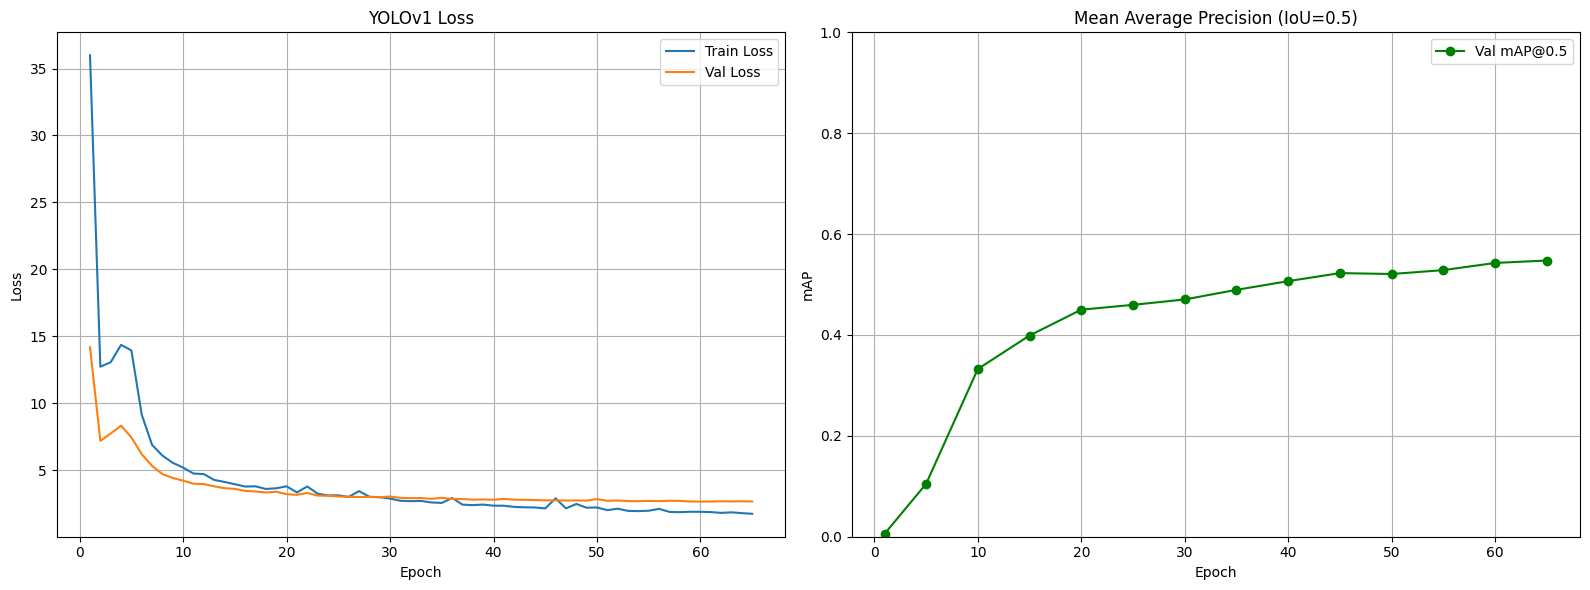

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(train_losses) + 1)

# Loss curves
axes[0].plot(epochs_range, train_losses, label="Train Loss")
axes[0].plot(epochs_range, val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("YOLOv1 Loss")
axes[0].legend()
axes[0].grid(True)

# mAP curve (only non-zero values)
map_epochs = [e for e, m in zip(epochs_range, val_maps) if m > 0]
map_values = [m for m in val_maps if m > 0]
axes[1].plot(map_epochs, map_values, "o-", label="Val mAP@0.5", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("Mean Average Precision (IoU=0.5)")
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 9. Evaluation on Validation Set

In [14]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# -------------------------------------------------------------------------
# Step 1: Re-instantiate validation DataLoader with num_workers=0
# -------------------------------------------------------------------------
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_fn,
)

# -------------------------------------------------------------------------
# Step 2: Run a single evaluation pass over the validation dataset
# -------------------------------------------------------------------------
model.eval()

all_det_scores = {c: [] for c in range(NUM_CLASSES)}
all_det_is_tp = {c: [] for c in range(NUM_CLASSES)}
n_gt_per_class = {c: 0 for c in range(NUM_CLASSES)}

print("Evaluating validation set in a single pass...")

with torch.no_grad():
    for images, gt_boxes_list, gt_labels_list in val_loader:
        images = images.to(device)
        detections = detect_objects(
            model,
            images,
            S=S, B=B, C=NUM_CLASSES,
            conf_threshold=0.01,
            nms_threshold=NMS_THRESHOLD,
        )

        for idx in range(len(detections)):
            det = detections[idx]
            gt_boxes = gt_boxes_list[idx].to(device)
            gt_labels = gt_labels_list[idx].to(device)

            for c in range(NUM_CLASSES):
                n_gt_per_class[c] += (gt_labels == c).sum().item()

            gt_matched = torch.zeros(gt_boxes.size(0), dtype=torch.bool, device=device)

            for det_idx in range(det["boxes"].size(0)):
                det_box = det["boxes"][det_idx].unsqueeze(0)
                det_label = det["labels"][det_idx].item()
                det_score = det["scores"][det_idx].item()

                class_mask = (gt_labels == det_label)
                if class_mask.sum() == 0:
                    all_det_scores[det_label].append(det_score)
                    all_det_is_tp[det_label].append(False)
                    continue

                gt_class_boxes = gt_boxes[class_mask]
                gt_class_indices = torch.where(class_mask)[0]
                iou = compute_iou(det_box, gt_class_boxes).squeeze(0)
                best_iou, best_gt_local_idx = iou.max(dim=0)
                best_gt_global_idx = gt_class_indices[best_gt_local_idx]

                if best_iou >= 0.5 and not gt_matched[best_gt_global_idx]:
                    all_det_scores[det_label].append(det_score)
                    all_det_is_tp[det_label].append(True)
                    gt_matched[best_gt_global_idx] = True
                else:
                    all_det_scores[det_label].append(det_score)
                    all_det_is_tp[det_label].append(False)

# -------------------------------------------------------------------------
# Step 3: Compute VOC 11-point interpolated AP per class and overall mAP@0.5
# -------------------------------------------------------------------------
print("\n--- Per-Class Results ---")
aps = []

for c in range(NUM_CLASSES):
    n_gt = n_gt_per_class[c]
    class_name = CLASS_NAMES[c]

    if n_gt == 0:
        print(f"  {class_name:12s}: no GT objects")
        continue

    scores = np.array(all_det_scores[c])
    is_tp = np.array(all_det_is_tp[c], dtype=bool)

    if len(scores) == 0:
        print(f"  {class_name:12s}: AP = 0.0000 ({n_gt} GT objects, 0 detections)")
        aps.append(0.0)
        continue

    sort_idx = np.argsort(-scores)
    is_tp = is_tp[sort_idx]

    tp_cumsum = np.cumsum(is_tp)
    fp_cumsum = np.cumsum(~is_tp)
    recall = tp_cumsum / n_gt
    precision = tp_cumsum / (tp_cumsum + fp_cumsum)

    ap = 0.0
    for t in np.arange(0.0, 1.1, 0.1):
        prec_at_recall = precision[recall >= t]
        if len(prec_at_recall) > 0:
            ap += prec_at_recall.max()
    ap /= 11.0

    aps.append(ap)
    print(f"  {class_name:12s}: AP = {ap:.4f} ({n_gt} GT objects)")

val_map_final = np.mean(aps) if len(aps) > 0 else 0.0
print(f"\nVal mAP@0.5: {val_map_final:.4f}")

Evaluating validation set in a single pass...

--- Per-Class Results ---
  aeroplane   : AP = 0.6068 (285 GT objects)
  bicycle     : AP = 0.6403 (337 GT objects)
  bird        : AP = 0.4618 (459 GT objects)
  boat        : AP = 0.3975 (263 GT objects)
  bottle      : AP = 0.1904 (469 GT objects)
  bus         : AP = 0.6787 (213 GT objects)
  car         : AP = 0.5214 (1201 GT objects)
  cat         : AP = 0.7897 (358 GT objects)
  chair       : AP = 0.3120 (756 GT objects)
  cow         : AP = 0.4574 (244 GT objects)
  diningtable : AP = 0.5727 (206 GT objects)
  dog         : AP = 0.7655 (489 GT objects)
  horse       : AP = 0.7723 (348 GT objects)
  motorbike   : AP = 0.6537 (325 GT objects)
  person      : AP = 0.4299 (4528 GT objects)
  pottedplant : AP = 0.2194 (480 GT objects)
  sheep       : AP = 0.4705 (242 GT objects)
  sofa        : AP = 0.6195 (239 GT objects)
  train       : AP = 0.7680 (282 GT objects)
  tvmonitor   : AP = 0.5287 (308 GT objects)

Val mAP@0.5: 0.5428


# 10. Visualization of Detections
Run detections on sample test images and visualize the predicted bounding boxes with class labels and confidence scores.

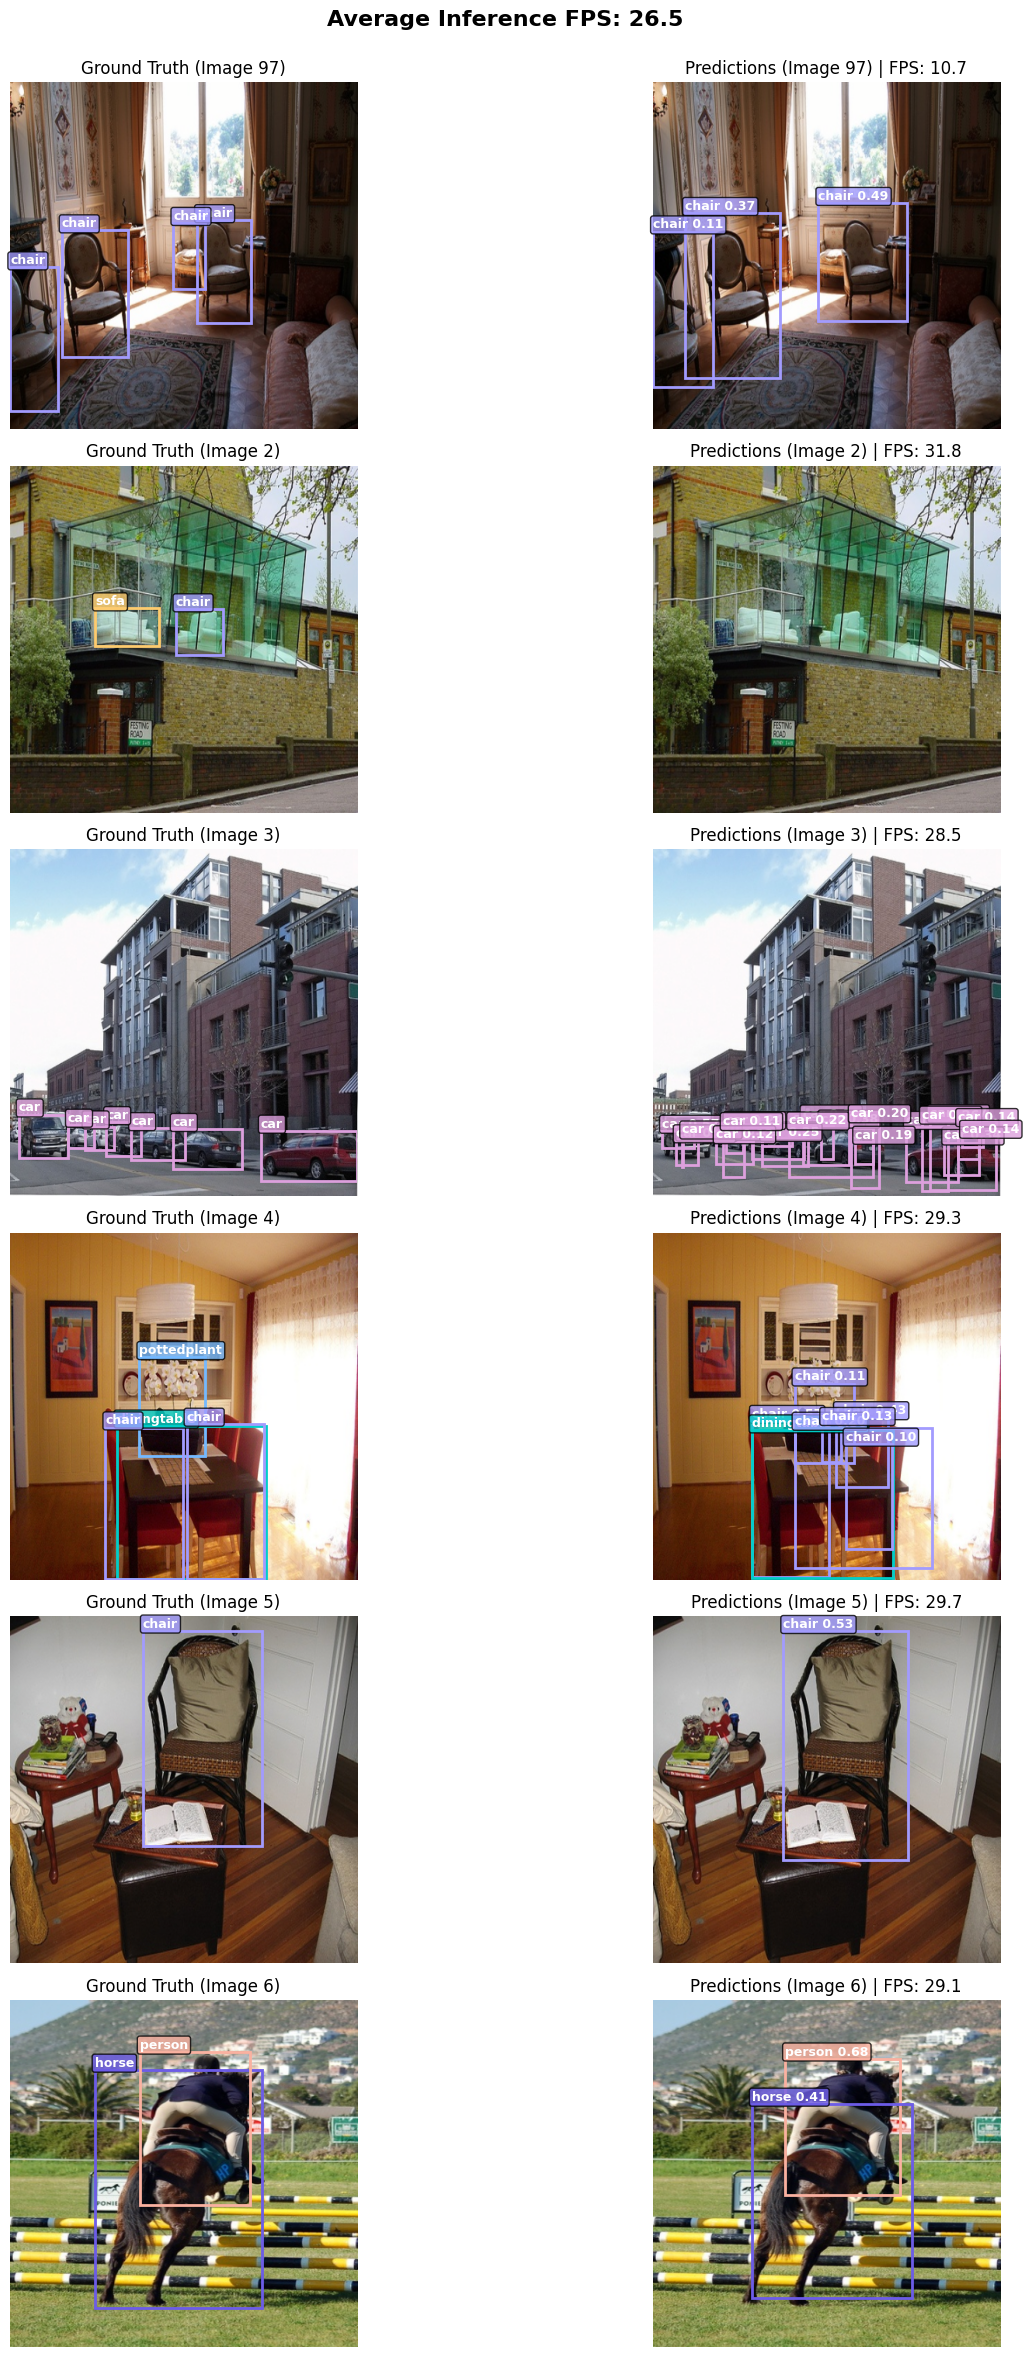

In [15]:
import time

# Color palette for each class (distinct colors for visualization)
CLASS_COLORS = [
    "black",       # 0:  background (not used)
    "#FF6B6B",     # 1:  aeroplane    (red)
    "#4ECDC4",     # 2:  bicycle      (teal)
    "#45B7D1",     # 3:  bird         (blue)
    "#96CEB4",     # 4:  boat         (green)
    "#FFEAA7",     # 5:  bottle       (yellow)
    "#DDA0DD",     # 6:  bus          (plum)
    "#FF8C42",     # 7:  car          (orange)
    "#A29BFE",     # 8:  cat          (lavender)
    "#FD79A8",     # 9:  chair        (pink)
    "#00CEC9",     # 10: cow          (cyan)
    "#E17055",     # 11: diningtable  (burnt orange)
    "#6C5CE7",     # 12: dog          (purple)
    "#55EFC4",     # 13: horse        (mint)
    "#FAB1A0",     # 14: motorbike    (salmon)
    "#74B9FF",     # 15: person       (sky blue)
    "#81ECEC",     # 16: pottedplant  (aqua)
    "#FDCB6E",     # 17: sheep        (gold)
    "#E84393",     # 18: sofa         (magenta)
    "#00B894",     # 19: train        (emerald)
    "#636E72",     # 20: tvmonitor    (grey)
]

# ImageNet denormalization for visualization
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)


def visualize_detections(model, dataset, n_samples=8, conf_threshold=0.3, fixed_indices=None):
    """Visualize object detections on sample images and calculate FPS.

    Shows side-by-side: (left) ground-truth boxes, (right) predicted boxes.
    """
    model.eval()
    
    # 1. Use fixed indices if provided to ensure the same images are used across different models
    if fixed_indices is not None:
        indices = fixed_indices[:n_samples]
    else:
        indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    fig, axes = plt.subplots(len(indices), 2, figsize=(16, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, 2)

    total_fps = 0.0

    for row, idx in enumerate(indices):
        image, gt_boxes, gt_labels = dataset[idx]

        image_batch = image.unsqueeze(0).to(device)
        
        # 2. FPS Calculation
        # Synchronize before starting the timer to ensure accurate measurement on GPU
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start_time = time.time()
        
        # Disable gradient calculation for faster inference
        with torch.no_grad():
            detections = detect_objects(
                model, image_batch,
                conf_threshold=conf_threshold, nms_threshold=NMS_THRESHOLD,
            )[0]
            
        # Synchronize again before stopping the timer
        if device.type == 'cuda':
            torch.cuda.synchronize()
        end_time = time.time()
        
        # Calculate FPS for the current image
        inference_time = end_time - start_time
        fps = 1.0 / inference_time if inference_time > 0 else 0.0
        total_fps += fps

        # Denormalize image for display
        img_display = denormalize(image).permute(1, 2, 0).numpy()

        # --- Ground Truth (left column) ---
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"Ground Truth (Image {idx})", fontsize=12)
        axes[row, 0].axis("off")

        for j in range(gt_boxes.size(0)):
            box = gt_boxes[j].numpy() * IMG_SIZE  # Scale to pixel coords
            label = gt_labels[j].item()
            color = CLASS_COLORS[label]
            rect = patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor=color, facecolor="none",
            )
            axes[row, 0].add_patch(rect)
            axes[row, 0].text(
                box[0], box[1] - 4, CLASS_NAMES[label],
                color="white", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8),
            )

        # --- Predictions (right column) ---
        axes[row, 1].imshow(img_display)
        # Display FPS in the title of the prediction
        axes[row, 1].set_title(f"Predictions (Image {idx}) | FPS: {fps:.1f}", fontsize=12)
        axes[row, 1].axis("off")

        det_boxes = detections["boxes"].cpu()
        det_labels = detections["labels"].cpu()
        det_scores = detections["scores"].cpu()

        for j in range(det_boxes.size(0)):
            box = det_boxes[j].numpy() * IMG_SIZE
            label = det_labels[j].item()
            score = det_scores[j].item()
            color = CLASS_COLORS[label]
            rect = patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor=color, facecolor="none",
            )
            axes[row, 1].add_patch(rect)
            axes[row, 1].text(
                box[0], box[1] - 4, f"{CLASS_NAMES[label]} {score:.2f}",
                color="white", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8),
            )

    # Display the average FPS over all sample images
    avg_fps = total_fps / len(indices)
    plt.suptitle(f"Average Inference FPS: {avg_fps:.1f}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(top=0.95) # Adjust layout to fit the suptitle
    plt.show()

# Define common indices to be used across all your notebooks (SSD, YOLO, RCNN)
common_eval_indices = [97, 2, 3, 4, 5, 6] 
visualize_detections(model, val_dataset, n_samples=6, fixed_indices=common_eval_indices, conf_threshold=0.1)